In [1]:
# Cell 1: Imports and Setup
import vtk
import numpy as np
from vtk.util import numpy_support as VN
import matplotlib.pyplot as plt
import os

# Ensure plots appear inline in Jupyter
%matplotlib inline 

In [ ]:
# Cell 2: Configuration
VTK_DIR = 'VTK'
CT_DATA_FILE = 'large3d/subvolume.npy'
VOXEL_RESOLUTION = 3.0035e-6 # meters/voxel (MUST MATCH SIMULATION SCALE)
OUTPUT_DIR = 'figures_vis_notebook' # Optional: for saving figures

# Create output directory if needed (useful even in notebook)
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Created output directory: {OUTPUT_DIR}")

In [3]:
# Cell 3: Load CT Data
print(f"Loading CT data from {CT_DATA_FILE}...")
if not os.path.exists(CT_DATA_FILE):
    print(f"Error: CT data file not found at {CT_DATA_FILE}")
    ct_data = None # Handle error downstream
else:
    try:
        ct_data = np.load(CT_DATA_FILE)
        Nx_ct, Ny_ct, Nz_ct = ct_data.shape
        print(f"CT data shape: ({Nx_ct}, {Ny_ct}, {Nz_ct})")
        # Calculate physical dimensions
        Lx = Nx_ct * VOXEL_RESOLUTION
        Ly = Ny_ct * VOXEL_RESOLUTION
        Lz = Nz_ct * VOXEL_RESOLUTION
    except Exception as e:
        print(f"Error loading CT data: {e}")
        ct_data = None

Loading CT data from large3d/subvolume.npy...
CT data shape: (200, 200, 200)


In [4]:
# Cell 4: Define Parameters for Visualization
# --- INTERACTIVE PART: Modify these values as needed ---
TIME_STEPS_TO_PLOT = [0, 300, 500] # List of time steps (must exist in VTK_DIR)
SLICE_DIMENSION = 'X'      # Dimension to slice ('X', 'Y', or 'Z')
SLICE_FRACTION = 0.5       # Fractional position (0.0-1.0) or set SLICE_INDEX below
# SLICE_INDEX = 100        # Alternatively, set an integer index directly
# --- End INTERACTIVE PART ---

# Determine slice index if fraction is given
if 'SLICE_INDEX' not in locals() and ct_data is not None:
    if SLICE_DIMENSION.upper() == 'Z':
        max_idx = ct_data.shape[2] - 1
    elif SLICE_DIMENSION.upper() == 'Y':
        max_idx = ct_data.shape[1] - 1
    elif SLICE_DIMENSION.upper() == 'X':
        max_idx = ct_data.shape[0] - 1
    else:
        max_idx = -1 # Will cause error below if SLICE_DIMENSION is invalid
        
    if max_idx >= 0:
        SLICE_INDEX = int(max_idx * SLICE_FRACTION)
    else:
        print(f"Error: Invalid SLICE_DIMENSION '{SLICE_DIMENSION}'.")
        SLICE_INDEX = -1 # Mark as invalid
elif 'SLICE_INDEX' in locals():
     print(f"Using specified SLICE_INDEX = {SLICE_INDEX}")
     

In [5]:
# Cell 5: Extract CT Slice
ct_slice_2d = None
slice_info = {}

if ct_data is not None and SLICE_INDEX >= 0:
    try:
        slice_coord = (SLICE_INDEX + 0.5) * VOXEL_RESOLUTION
        slice_dim_upper = SLICE_DIMENSION.upper()

        if slice_dim_upper == 'Z':
            if SLICE_INDEX < ct_data.shape[2]:
                ct_slice_2d = ct_data[:, :, SLICE_INDEX].T # Transpose for imshow
                slice_axis_idx = 2
                xlabel, ylabel = 'x [m]', 'y [m]'
                plot_extent = [0, Lx, 0, Ly]
                print(f"Selected CT slice: Z = {SLICE_INDEX} (coord: {slice_coord:.3e} m)")
            else: print(f"Error: Slice index {SLICE_INDEX} out of bounds for Z (max {ct_data.shape[2]-1}).")
        elif slice_dim_upper == 'Y':
             if SLICE_INDEX < ct_data.shape[1]:
                 ct_slice_2d = ct_data[:, SLICE_INDEX, :].T
                 slice_axis_idx = 1
                 xlabel, ylabel = 'x [m]', 'z [m]'
                 plot_extent = [0, Lx, 0, Lz]
                 print(f"Selected CT slice: Y = {SLICE_INDEX} (coord: {slice_coord:.3e} m)")
             else: print(f"Error: Slice index {SLICE_INDEX} out of bounds for Y (max {ct_data.shape[1]-1}).")
        elif slice_dim_upper == 'X':
             if SLICE_INDEX < ct_data.shape[0]:
                 ct_slice_2d = ct_data[SLICE_INDEX, :, :].T
                 slice_axis_idx = 0
                 xlabel, ylabel = 'y [m]', 'z [m]'
                 plot_extent = [0, Ly, 0, Lz]
                 print(f"Selected CT slice: X = {SLICE_INDEX} (coord: {slice_coord:.3e} m)")
             else: print(f"Error: Slice index {SLICE_INDEX} out of bounds for X (max {ct_data.shape[0]-1}).")
        else:
            print(f"Error: Invalid SLICE_DIMENSION '{SLICE_DIMENSION}'.")

        if ct_slice_2d is not None:
            slice_info = {
                'slice_coord': slice_coord,
                'slice_axis_idx': slice_axis_idx,
                'xlabel': xlabel,
                'ylabel': ylabel,
                'plot_extent': plot_extent
            }
    except Exception as e:
        print(f"Error extracting CT slice: {e}")
        ct_slice_2d = None
else:
    print("Skipping CT slice extraction due to previous errors.")


Selected CT slice: X = 99 (coord: 2.988e-04 m)


In [6]:
# Cell 6: Load and Process Simulation Data for Slicing
sim_data_all_times = {} # Store full data for histograms later
sim_data_slice_all_times = {} # Store only sliced data

slice_tolerance = VOXEL_RESOLUTION / 2.0

print("\nLoading and processing simulation data...")
for t in TIME_STEPS_TO_PLOT:
    vtk_file = os.path.join(VTK_DIR, f'case_{t}.vtk')
    print(f"Processing {vtk_file}...")
    
    sim_data_full = None # Reset for each time step
    if not os.path.exists(vtk_file):
        print(f"  Error: VTK file not found.")
        continue

    # Load VTK
    reader = vtk.vtkUnstructuredGridReader()
    reader.SetFileName(vtk_file)
    reader.ReadAllScalarsOn()
    reader.ReadAllVectorsOn()
    reader.Update()
    data = reader.GetOutput()

    if data is None or data.GetNumberOfCells() == 0:
        print(f"  Error: Failed to read data or no cells found.")
        continue

    # Check arrays
    if data.GetCellData().GetArray('U') is None or data.GetCellData().GetArray('p') is None:
        print(f"  Error: 'U' or 'p' array not found.")
        continue
        
    # Extract required data
    try:
        cell_centers_filter = vtk.vtkCellCenters()
        cell_centers_filter.SetInputData(data)
        cell_centers_filter.Update()
        centers_data = cell_centers_filter.GetOutput()
        points_vtk = centers_data.GetPoints().GetData()
        coords = VN.vtk_to_numpy(points_vtk)
        x_coords, y_coords, z_coords = coords[:,0], coords[:,1], coords[:,2]

        U = VN.vtk_to_numpy(data.GetCellData().GetArray('U'))
        p = VN.vtk_to_numpy(data.GetCellData().GetArray('p'))
        Umag = np.sqrt(U[:,0]**2 + U[:,1]**2 + U[:,2]**2)
        
        sim_data_full = {'x': x_coords, 'y': y_coords, 'z': z_coords, 'Umag': Umag, 'p': p}
        sim_data_all_times[t] = sim_data_full # Store full data for histogram
        print(f"  Loaded data for time {t}.")

    except Exception as e:
        print(f"  Error extracting data from VTK for time {t}: {e}")
        continue # Skip to next time step

    # Filter for slice (only if sim data loaded and slice info exists)
    if sim_data_full and slice_info:
        coords_all = np.stack((sim_data_full['x'], sim_data_full['y'], sim_data_full['z']), axis=-1)
        slice_mask = np.abs(coords_all[:, slice_info['slice_axis_idx']] - slice_info['slice_coord']) < slice_tolerance

        if not np.any(slice_mask):
            print(f"  Warning: No simulation cells found near slice for time {t}.")
            continue # No slice data for this time step

        # Determine plot coords based on slice dimension
        if SLICE_DIMENSION.upper() == 'Z':
             x_plot = sim_data_full['x'][slice_mask]
             y_plot = sim_data_full['y'][slice_mask]
        elif SLICE_DIMENSION.upper() == 'Y':
             x_plot = sim_data_full['x'][slice_mask]
             y_plot = sim_data_full['z'][slice_mask]
        elif SLICE_DIMENSION.upper() == 'X':
             x_plot = sim_data_full['y'][slice_mask]
             y_plot = sim_data_full['z'][slice_mask]
        else: # Should not happen if checked earlier
            continue 
            
        sim_data_slice_all_times[t] = {
            'x_plot': x_plot,
            'y_plot': y_plot,
            'Umag_slice': sim_data_full['Umag'][slice_mask],
            'p_slice': sim_data_full['p'][slice_mask]
        }
        print(f"  Found {len(x_plot)} simulation cells near slice for time {t}.")


Loading and processing simulation data...
Processing VTK/case_0.vtk...
  Loaded data for time 0.
  Found 6209 simulation cells near slice for time 0.
Processing VTK/case_300.vtk...
  Loaded data for time 300.
  Found 6209 simulation cells near slice for time 300.
Processing VTK/case_500.vtk...
  Loaded data for time 500.
  Found 6209 simulation cells near slice for time 500.


### Data Analyze

(6209,)
(6209,)
(6209,)


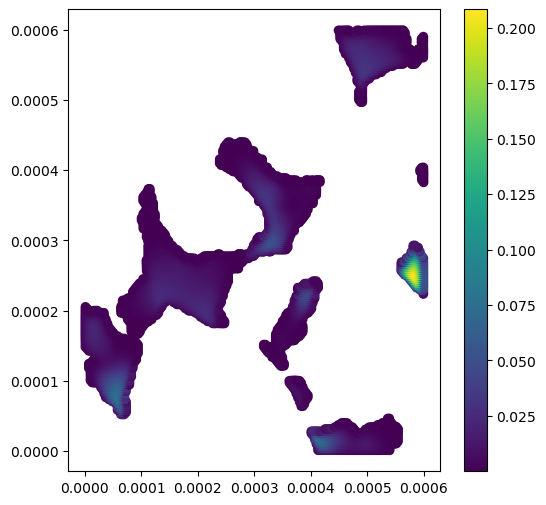

Velocity magnitude min: 1.645424596574685e-08
Velocity magnitude max: 0.20843926072120667
Velocity magnitude mean: 0.015955420210957527
Velocity magnitude median: 0.009682361967861652


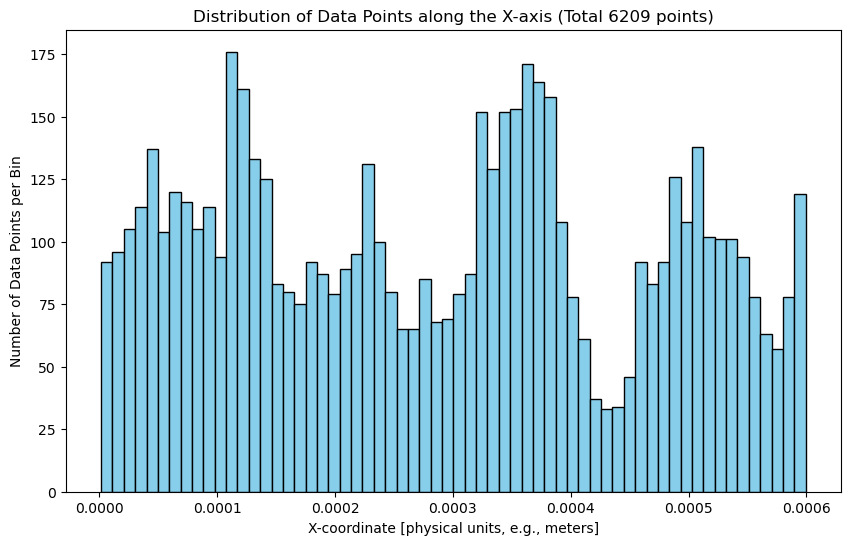

In [30]:
print(sim_data_slice_all_times[500]['Umag_slice'].shape)
print(sim_data_slice_all_times[500]['x_plot'].shape)
print(sim_data_slice_all_times[500]['y_plot'].shape)

# plot velocity magnitude slice
f = plt.figure(figsize=(6, 6))
plt.scatter(sim_data_slice_all_times[500]['x_plot'], sim_data_slice_all_times[500]['y_plot'], c=sim_data_slice_all_times[500]['Umag_slice'], cmap='viridis')
plt.colorbar()
plt.show()


x_plot_data = sim_data_slice_all_times[500]['x_plot']



x_min = np.min(x_plot_data)
x_max = np.max(x_plot_data)

num_points = len(x_plot_data)
# Adjust number of bins, e.g., based on data size or Freedman-Diaconis rule for a start
# For simplicity, let's use a reasonable number like 50 or 100.
# You can experiment with this value.
num_bins = min(max(20, int(num_points / 100)), 100) # Heuristic for bins

plt.figure(figsize=(10, 6))

# Plotting the histogram
counts, bin_edges, patches = plt.hist(x_plot_data, bins=num_bins, color='skyblue', edgecolor='black')

plt.title(f'Distribution of Data Points along the X-axis (Total {num_points} points)')
plt.xlabel('X-coordinate [physical units, e.g., meters]')
plt.ylabel('Number of Data Points per Bin')

# print out stats summary of velocity magnitude
print(f"Velocity magnitude min: {np.min(sim_data_slice_all_times[500]['Umag_slice'])}")
print(f"Velocity magnitude max: {np.max(sim_data_slice_all_times[500]['Umag_slice'])}")
print(f"Velocity magnitude mean: {np.mean(sim_data_slice_all_times[500]['Umag_slice'])}")
print(f"Velocity magnitude median: {np.median(sim_data_slice_all_times[500]['Umag_slice'])}")





Generating CT vs Velocity Plots...


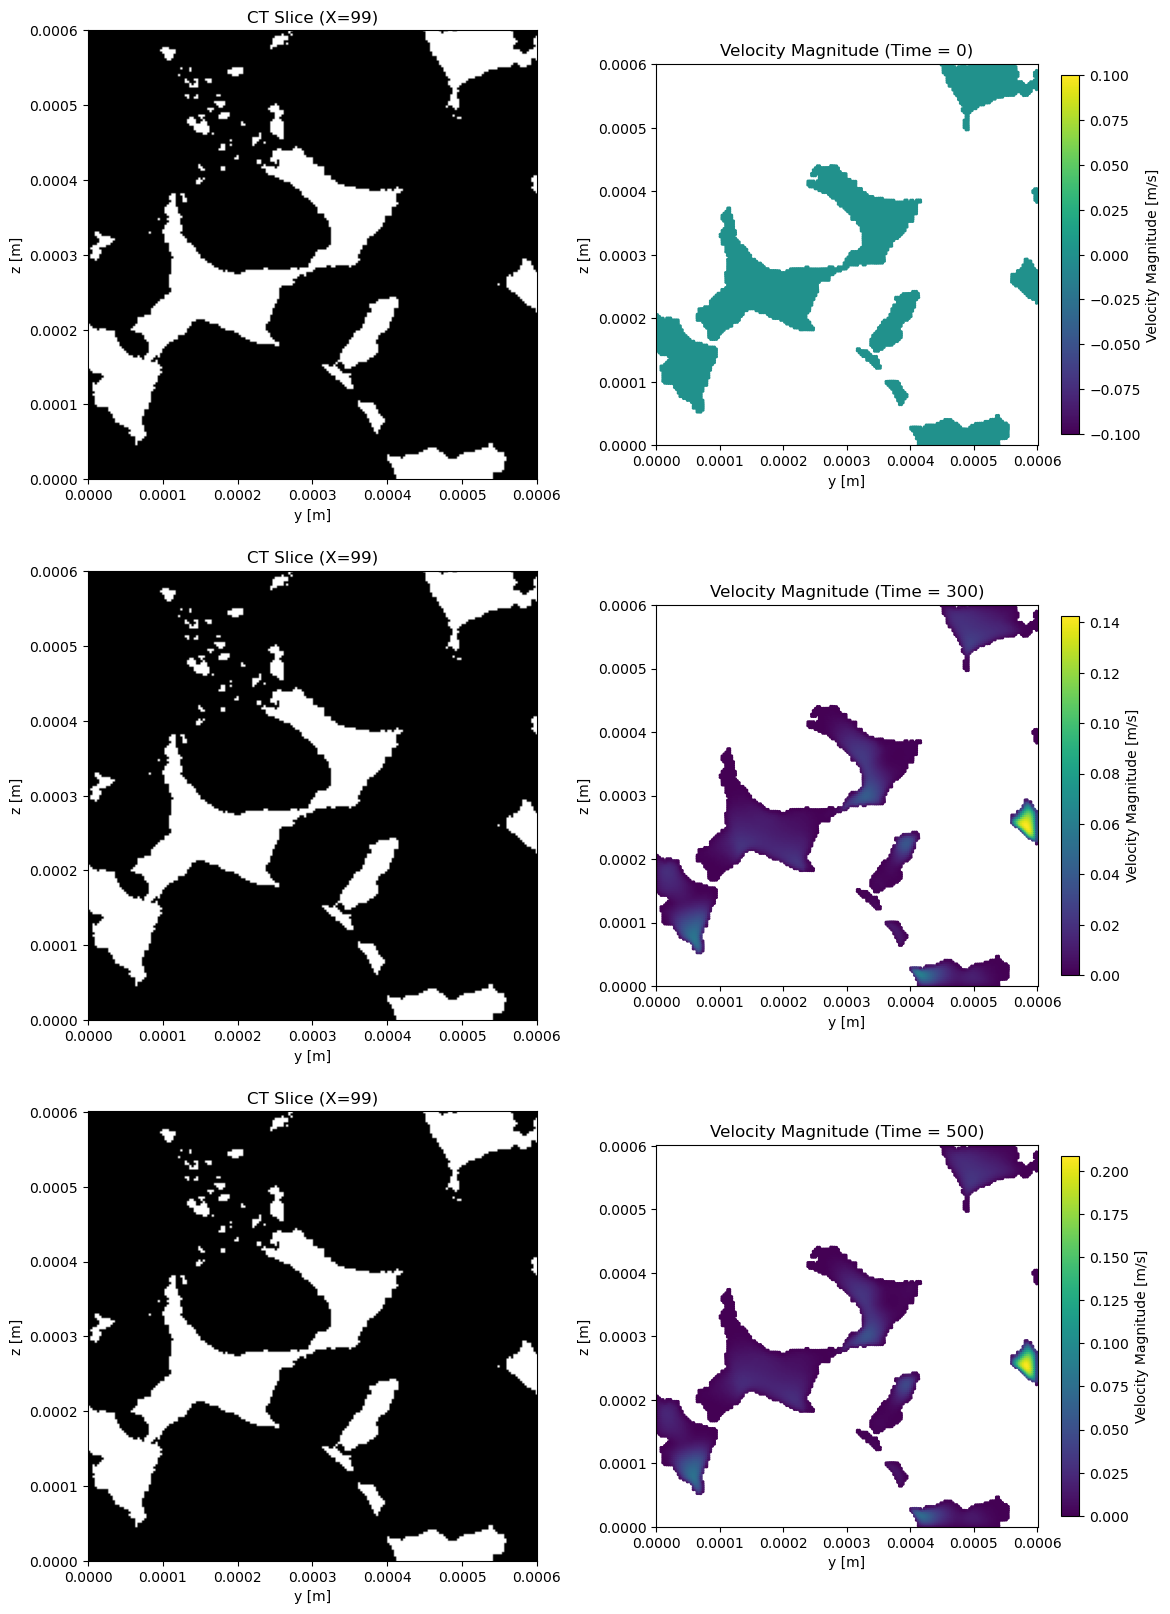

In [14]:
# Cell 7: Plot CT Slice vs Velocity Magnitude Comparison
print("\nGenerating CT vs Velocity Plots...")
if ct_slice_2d is not None and slice_info and sim_data_slice_all_times:
    num_plots = len(sim_data_slice_all_times)
    if num_plots > 0:
        fig_vel, axes_vel = plt.subplots(nrows=num_plots, ncols=2, figsize=(12, 5.5 * num_plots), squeeze=False)
        
        plot_row = 0
        for t, data_t_slice in sim_data_slice_all_times.items():
            ax_ct = axes_vel[plot_row, 0]
            ax_sim = axes_vel[plot_row, 1]

            # Plot CT Slice
            ax_ct.imshow(ct_slice_2d, cmap='gray', origin='lower', extent=slice_info['plot_extent'])
            ax_ct.set_title(f'CT Slice ({SLICE_DIMENSION.upper()}={SLICE_INDEX})')
            ax_ct.set_xlabel(slice_info['xlabel'])
            ax_ct.set_ylabel(slice_info['ylabel'])
            ax_ct.set_aspect('equal')

            # Plot Velocity Magnitude Slice
            sc = ax_sim.scatter(data_t_slice['x_plot'], data_t_slice['y_plot'], c=data_t_slice['Umag_slice'], 
                                s=2, cmap='viridis', vmin=0) # Set vmin=0
            ax_sim.set_title(f'Velocity Magnitude (Time = {t})')
            ax_sim.set_xlabel(slice_info['xlabel'])
            ax_sim.set_ylabel(slice_info['ylabel'])
            ax_sim.set_xlim(slice_info['plot_extent'][0], slice_info['plot_extent'][1])
            ax_sim.set_ylim(slice_info['plot_extent'][2], slice_info['plot_extent'][3])
            ax_sim.set_aspect('equal')
            fig_vel.colorbar(sc, ax=ax_sim, label='Velocity Magnitude [m/s]', shrink=0.8)
            
            plot_row += 1

        plt.tight_layout(pad=2.0)
        
        # Optional: Save figure
        # fig_vel_path = os.path.join(OUTPUT_DIR, 'figure_CT_vs_Velocity_comparison.png')
        # plt.savefig(fig_vel_path, dpi=150)
        
        plt.show()
    else:
        print("No simulation data slices found for the specified time steps.")
elif ct_slice_2d is None:
     print("Skipping CT vs Velocity plots because CT slice could not be generated.")
else:
     print("Skipping CT vs Velocity plots because no simulation data slices could be generated.")


Generating CT vs Pressure Plots...


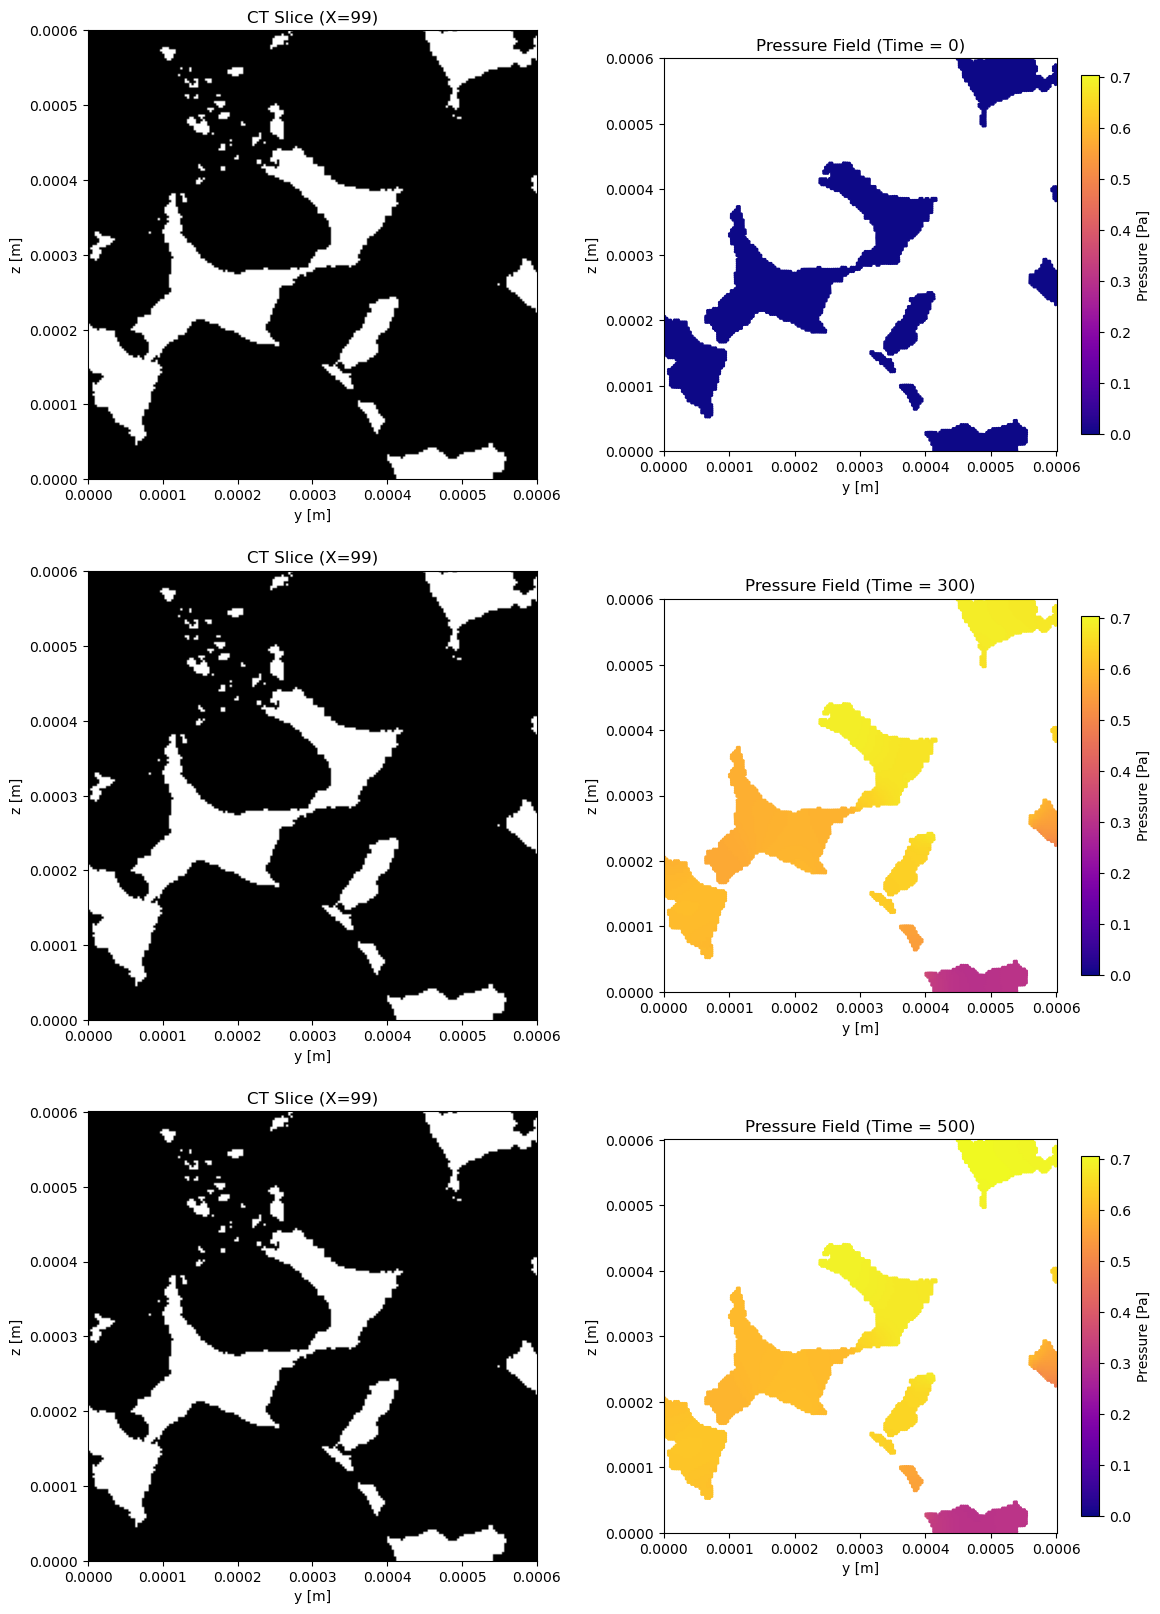

In [15]:
# Cell 8: Plot CT Slice vs Pressure Comparison
print("\nGenerating CT vs Pressure Plots...")
if ct_slice_2d is not None and slice_info and sim_data_slice_all_times:
    num_plots = len(sim_data_slice_all_times)
    if num_plots > 0:
        fig_p, axes_p = plt.subplots(nrows=num_plots, ncols=2, figsize=(12, 5.5 * num_plots), squeeze=False)

        # Determine pressure range across all valid slices for consistent colorbar
        all_p_slice = np.concatenate([data['p_slice'] for data in sim_data_slice_all_times.values()])
        # --- Corrected min/max calculation ---
        if len(all_p_slice) > 0:
            p_min = np.min(all_p_slice)
            p_max = np.max(all_p_slice)
        else:
            p_min, p_max = 0, 1 # Default range if no data
        # --- End Correction ---

        plot_row = 0
        for t, data_t_slice in sim_data_slice_all_times.items():
            ax_ct = axes_p[plot_row, 0]
            ax_sim = axes_p[plot_row, 1]

            # Plot CT Slice
            ax_ct.imshow(ct_slice_2d, cmap='gray', origin='lower', extent=slice_info['plot_extent'])
            ax_ct.set_title(f'CT Slice ({SLICE_DIMENSION.upper()}={SLICE_INDEX})')
            ax_ct.set_xlabel(slice_info['xlabel'])
            ax_ct.set_ylabel(slice_info['ylabel'])
            ax_ct.set_aspect('equal')

            # Plot Pressure Slice
            sc = ax_sim.scatter(data_t_slice['x_plot'], data_t_slice['y_plot'], c=data_t_slice['p_slice'],
                                s=2, cmap='plasma', vmin=p_min, vmax=p_max)
            ax_sim.set_title(f'Pressure Field (Time = {t})')
            ax_sim.set_xlabel(slice_info['xlabel'])
            ax_sim.set_ylabel(slice_info['ylabel'])
            ax_sim.set_xlim(slice_info['plot_extent'][0], slice_info['plot_extent'][1])
            ax_sim.set_ylim(slice_info['plot_extent'][2], slice_info['plot_extent'][3])
            ax_sim.set_aspect('equal')
            fig_p.colorbar(sc, ax=ax_sim, label='Pressure [Pa]', shrink=0.8)

            plot_row += 1

        plt.tight_layout(pad=2.0)

        # Optional: Save figure
        # fig_p_path = os.path.join(OUTPUT_DIR, 'figure_CT_vs_Pressure_comparison.png')
        # plt.savefig(fig_p_path, dpi=150)

        plt.show()
    else:
        print("No simulation data slices found for the specified time steps.")
elif ct_slice_2d is None:
     print("Skipping CT vs Pressure plots because CT slice could not be generated.")
else:
     print("Skipping CT vs Pressure plots because no simulation data slices could be generated.")


Generating Velocity Histograms...
Note: Could not set y-axis to log scale (likely due to data range).


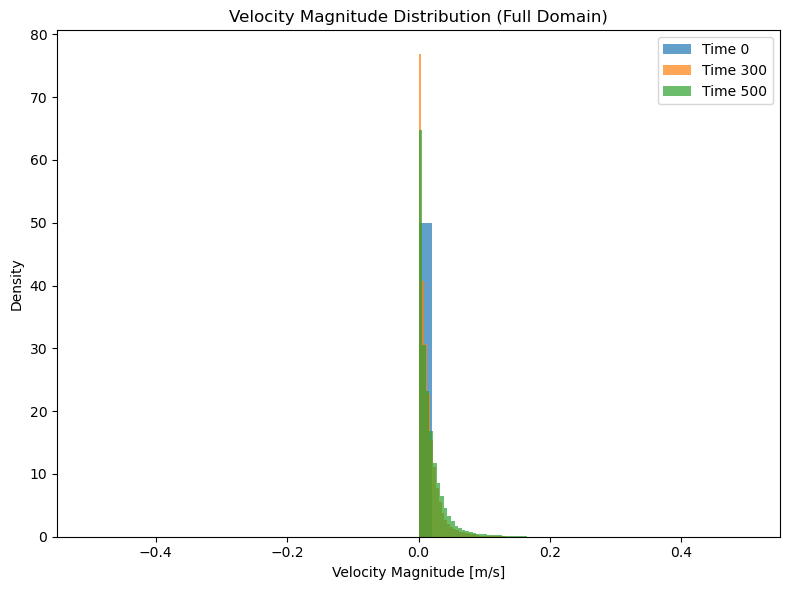


Notebook visualization cells finished.


In [16]:
# Cell 9: Plot Velocity Magnitude Histograms
print("\nGenerating Velocity Histograms...")
if sim_data_all_times: # Check if any sim data was loaded successfully
    fig_hist, ax_hist = plt.subplots(figsize=(8, 6))
    has_hist_data = False
    
    for t, data_full in sim_data_all_times.items():
        if 'Umag' in data_full and len(data_full['Umag']) > 0:
             ax_hist.hist(data_full['Umag'], bins=50, alpha=0.7, label=f'Time {t}', density=True)
             has_hist_data = True
        else:
             print(f"Warning: Missing or empty 'Umag' data for histogram at time {t}")

    if has_hist_data:
        ax_hist.set_title('Velocity Magnitude Distribution (Full Domain)')
        ax_hist.set_xlabel('Velocity Magnitude [m/s]')
        ax_hist.set_ylabel('Density')
        ax_hist.legend()
        # Set y-axis to log scale only if data warrants it
        y_lims = ax_hist.get_ylim()
        if y_lims[1] > y_lims[0] > 0: 
             ax_hist.set_yscale('log')
        else:
            print("Note: Could not set y-axis to log scale (likely due to data range).")
            
        plt.tight_layout()
        
        # Optional: Save figure
        # fig_hist_path = os.path.join(OUTPUT_DIR, 'figure_Velocity_Histograms.png')
        # plt.savefig(fig_hist_path, dpi=150)
        
        plt.show()
    else:
        print("No valid data found for histograms.")
else:
    print("Skipping histograms because no simulation data could be loaded.")

print("\nNotebook visualization cells finished.")